# Day 13 — End-to-End ML Project: House Price Predictor

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score

In [2]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)
print(df.head())
print(df.info())
print(df.isna().sum())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float6

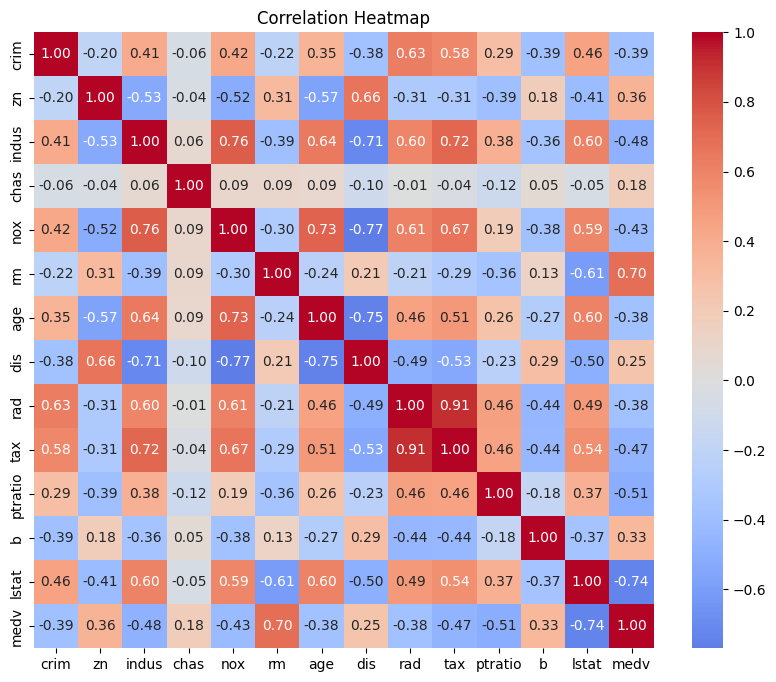

In [3]:
#wanted to do some feature engineering but i'm confused. The dataset looks enough organised to me.


fig, ax = plt.subplots(figsize=(10, 8))
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap')
plt.show()

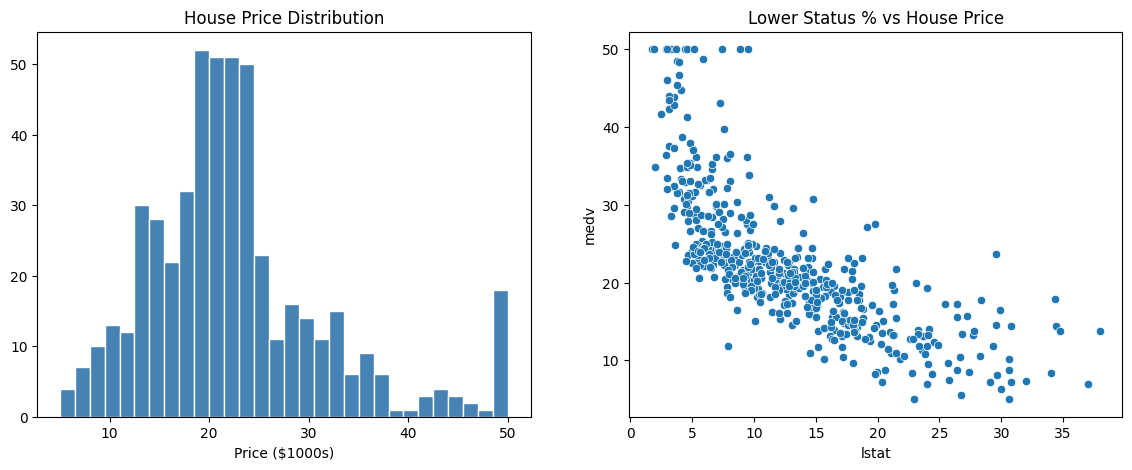

In [4]:
#crim, indus, nox, age, rad, tax, ptratio, lstat higher means house price will be lower
# zn, chas, rm, dis, b higher mean house price will be higher.


#Plot target variable Distribution (from AI)
fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].hist(df['medv'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('House Price Distribution')
axes[0].set_xlabel('Price ($1000s)')

#Check for outliers in strongest predictors
sns.scatterplot(data=df, x='lstat', y='medv', ax=axes[1])
axes[1].set_title('Lower Status % vs House Price')
plt.show()

In [5]:
x = df.drop(columns=['medv'])
y = df['medv']

print(x.shape)
print(y.shape)

(506, 13)
(506,)


In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42)

print(x_train.shape)
print(x_test.shape)

(404, 13)
(102, 13)


In [14]:
lr = LinearRegression()

In [15]:
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.11, 0.03, 0.04,...,-0.92, 0.01,-0.51]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['crim','zn','indus',...,'ptratio','b','lstat']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,30.25
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13


In [29]:
y_pred = lr.predict(x_test)

print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))

0.6687594935356317
3.1890919658878416
24.291119474973538


In [21]:
lr_cv_scores = cross_val_score(lr, x, y, cv=5, scoring='r2')
lr_cv_scores_mae = cross_val_score(lr, x, y, cv=5, scoring='neg_mean_absolute_error')
print(lr_cv_scores.mean())
print(lr_cv_scores_mae.mean())

0.3532759243958762
-4.249968544192553


In [26]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])

In [28]:
for name, model in[('lr with scaling', pipeline_lr),
                   ('lr without scaling', LinearRegression()),
                   ('rf with scaling', pipeline_rf),
                   ('rf without scaling', RandomForestRegressor(random_state=42))]:
    scores_r2 = cross_val_score(model, x, y, cv=5, scoring='r2')
    scores_mae = cross_val_score(model, x, y, cv=5, scoring='neg_mean_absolute_error')

    print(f"{name}: R2 - {scores_r2.mean():.2f} and MAE {-scores_mae.mean():.2f}")

    
                   

lr with scaling: R2 - 0.35 and MAE 4.25
lr without scaling: R2 - 0.35 and MAE 4.25
rf with scaling: R2 - 0.62 and MAE 3.04
rf without scaling: R2 - 0.62 and MAE 3.04


In [34]:
import joblib
pipeline_rf.fit(x,y)
joblib.dump(pipeline_rf, 'house_model.pkl')
print("model saved.")

model saved.


In [32]:
print(x.columns.tolist())

['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']
